Importing dataset


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


In [2]:
df.info() #checking info we do have some missing values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,75.2500,D37,C
801,802,1,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
799,800,0,3,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S
229,230,0,3,"Lefebre, Miss. Mathilde",female,NaN,3,1,4133,25.4667,NaN,S


And one important thing is we dont need this ticket column because we have only ticket ids in this col which cannot don anything with this in prediction 

so i need to drop this ticket col

and same goes for name,passange_id we have nothing to do with name when predicting

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.shape

(891, 12)

In [6]:
#checking how many null do we have this data
df.isnull().sum()
#we do have so many missing values in this cabin iam thinking to drop this cabin col

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

we have so many missing values in this cabin so dropping this col

<Axes: xlabel='Survived', ylabel='count'>

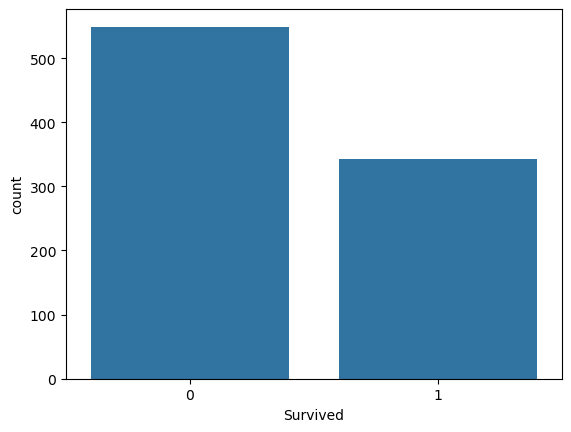

In [7]:
#plotting
import seaborn as sns
sns.countplot(x=df['Survived'])
#only few memeber actually survived from the graph

<Axes: ylabel='count'>

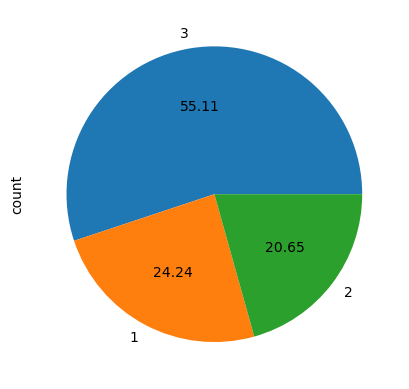

In [8]:
df["Pclass"].value_counts().plot(kind='pie',autopct="%.2f")
#from this we can get to know in this class 3 many people travelled

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

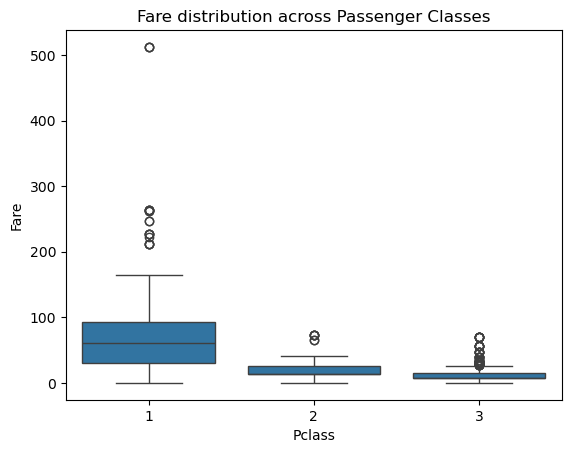

In [ ]:
import matplotlib.pyplot as plt
sns.boxplot(x=df["Pclass"], y=df["Fare"])
plt.title("Fare distribution across Passenger Classes")
plt.show()


We can see this here that for pclass 1 we have more price than pclasses 1 and 2

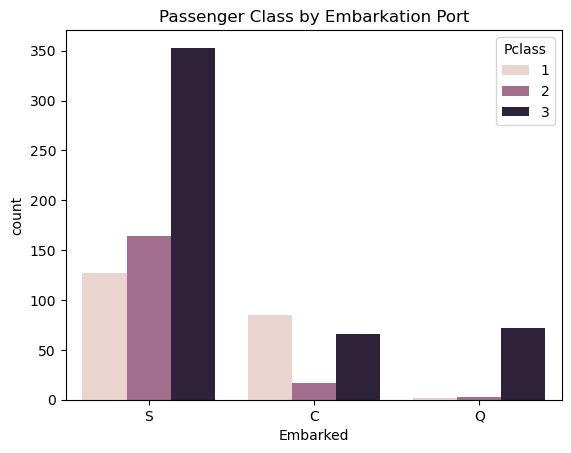

In [ ]:
sns.countplot(x=df["Embarked"], hue=df["Pclass"])

So many people actullay on boarded at this Southampton 

<Axes: ylabel='count'>

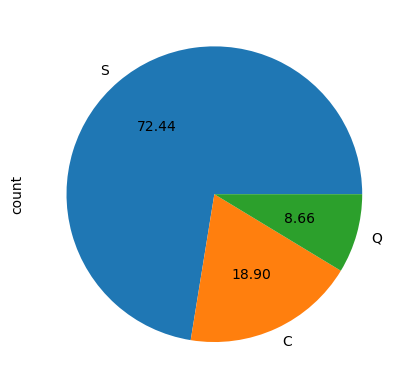

In [33]:
df['Embarked'].value_counts().plot(kind='pie',autopct="%.2f")

Over 72 % people boarded at are from this Southampton

<Axes: xlabel='Survived', ylabel='count'>

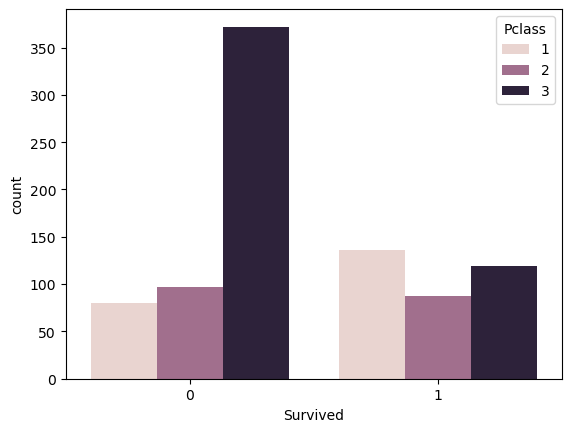

In [ ]:
sns.countplot(x=df['Survived'],hue=df['Pclass'])

From this grpah we can see that most of Pclass 3 poeple actually not able to survive

<Axes: xlabel='Survived', ylabel='count'>

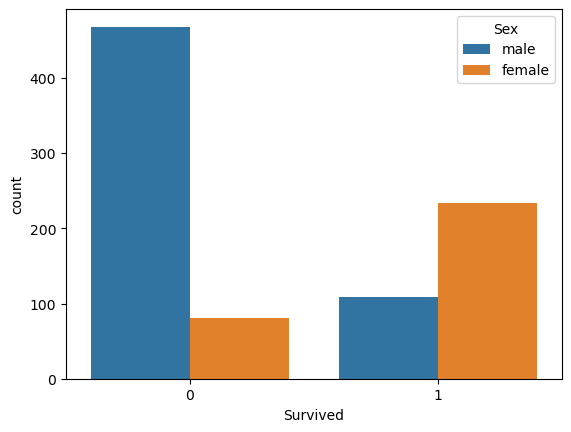

In [21]:
sns.countplot(x=df['Survived'],hue=df['Sex'])

From this graph we can see that most of the male memebers are not survived

<Axes: xlabel='Age'>

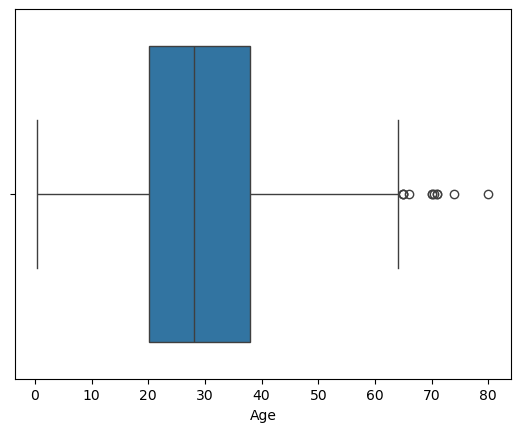

In [22]:
#lets check do we have outlier using this boxplot
sns.boxplot(x=df['Age'])

Yeah we have some oultiers in this age cols so we need to imput this col with median

<Axes: xlabel='Age'>

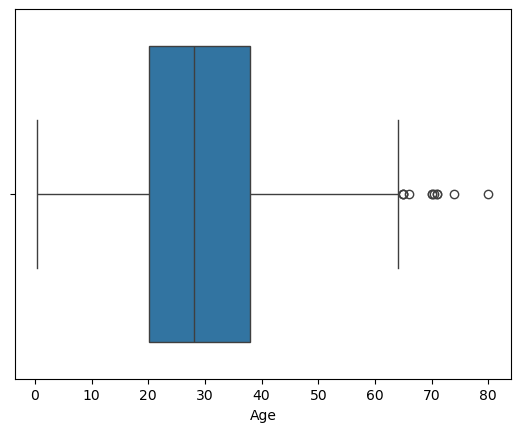

In [25]:
sns.boxplot(x=df['Age'])

In [30]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,6.95,8.3,6.4375,39.4,14.1083,13.8583,50.4958,5.0,9.8458,10.5167
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,...,0,0,0,0,0,0,0,0,0,0
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,...,0,0,0,0,0,0,0,0,0,0
816,817,0,3,"Heininen, Miss. Wendla Maria",female,23.0,0,0,STON/O2. 3101290,7.9250,...,0,0,0,0,0,0,0,0,0,0
718,719,0,3,"McEvoy, Mr. Michael",male,NaN,0,0,36568,15.5000,...,0,0,0,0,0,0,0,0,0,0
635,636,1,2,"Davis, Miss. Mary",female,28.0,0,0,237668,13.0000,...,0,0,0,0,0,0,0,0,0,0
474,475,0,3,"Strandberg, Miss. Ida Sofia",female,22.0,0,0,7553,9.8375,...,0,0,0,0,0,0,0,0,0,0
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,...,0,0,0,0,0,0,0,0,0,0
287,288,0,3,"Naidenoff, Mr. Penko",male,22.0,0,0,349206,7.8958,...,0,0,0,0,0,0,0,0,0,0
55,56,1,1,"Woolner, Mr. Hugh",male,NaN,0,0,19947,35.5000,...,0,0,0,0,0,0,0,0,0,0
570,571,1,2,"Harris, Mr. George",male,62.0,0,0,S.W./PP 752,10.5000,...,0,0,0,0,0,0,0,0,0,0
